### Step 1: Mount Google Drive and Navigate to the Data Folder

First, we need to mount your Google Drive to access the preprocessed dataset files. Then, we'll navigate to the specific folder where your data is stored.

In [1]:
from google.colab import drive
import os
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your data ZIP file in Google Drive
zip_file_path = '/content/drive/My Drive/FraudDetection-20260402T135013Z-3-001.zip'

# Define the destination directory for unzipping
unzip_destination_path = '/content/FraudDetection_unzipped'

# Create the destination directory if it doesn't exist
os.makedirs(unzip_destination_path, exist_ok=True)

print(f"Unzipping '{zip_file_path}' to '{unzip_destination_path}'...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_destination_path)
print("Unzipping complete.")

# Now, change the current working directory to the unzipped data folder
# We assume the zip file contains a single main folder inside it.
# Let's inspect the contents after unzipping to get the correct inner folder name

# List contents of the unzipped directory to find the actual data folder
unzipped_contents = os.listdir(unzip_destination_path)
print(f"Contents of unzipped directory '{unzip_destination_path}': {unzipped_contents}")

# Assuming the actual data folder is the first and only directory inside the unzipped path
# You might need to adjust this if your zip file extracts differently
actual_data_folder_name = unzip_destination_path + '/' + unzipped_contents[0]

os.chdir(actual_data_folder_name)

print(f"Current working directory changed to: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping '/content/drive/My Drive/FraudDetection-20260402T135013Z-3-001.zip' to '/content/FraudDetection_unzipped'...
Unzipping complete.
Contents of unzipped directory '/content/FraudDetection_unzipped': ['FraudDetection']
Current working directory changed to: /content/FraudDetection_unzipped/FraudDetection


### Step 2: Load Preprocessed Data and Print Shapes

Now, we'll load the `X_train.csv`, `X_test.csv`, `y_train.csv`, and `y_test.csv` files into pandas DataFrames. After loading, we'll print their shapes to confirm the data has been loaded correctly.

In [2]:
import pandas as pd
import os

# --- Diagnostic Step: List contents of current directory to verify file paths ---
print(f"\nListing contents of current directory ({os.getcwd()}):")
!ls -F
print("-------------------------------------------------------------------")
# Please review the output above to find the exact location of 'X_train.csv' etc.
# If the CSV files are in a subdirectory (e.g., 'data/X_train.csv'), update the paths below.

# Load the datasets, assuming they are in the 'cleaned_data/' subdirectory
X_train = pd.read_csv('cleaned_data/X_train.csv')
X_test = pd.read_csv('cleaned_data/X_test.csv')
y_train = pd.read_csv('cleaned_data/y_train.csv')
y_test = pd.read_csv('cleaned_data/y_test.csv')

# Print the shapes of the datasets
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

# Display first few rows of X_train to confirm loading
print('\nX_train head:')
display(X_train.head())


Listing contents of current directory (/content/FraudDetection_unzipped/FraudDetection):
cleaned_data/  dataset/
-------------------------------------------------------------------
Shape of X_train: (454902, 30)
Shape of X_test: (56962, 30)
Shape of y_train: (454902, 1)
Shape of y_test: (56962, 1)

X_train head:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time
0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.323963,1.413095
1,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.341275,0.624644
2,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,0.346835,-1.129186
3,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,...,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.328841,0.796203
4,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,...,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,-0.008994,-0.746606


### Step 3: Train a RandomForestClassifier Model

We will now import the `RandomForestClassifier` from scikit-learn, initialize it, and then train the model using your training data (`X_train` and `y_train`). We'll set a `random_state` for reproducibility.

In [3]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
# n_estimators: The number of trees in the forest.
# random_state: Controls the randomness of the bootstrapping of samples and features.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

# Train the model
print("Training Random Forest Classifier...")
rf_model.fit(X_train, y_train.values.ravel()) # .values.ravel() converts y_train to a 1D array
print("Random Forest Classifier training complete.")

Training Random Forest Classifier...
Random Forest Classifier training complete.


### Step 4: Evaluate the Model

After training, we will evaluate the Random Forest model's performance on the test set (`X_test` and `y_test`) using several key metrics relevant for imbalanced datasets: accuracy, precision, recall, F1-score, and ROC-AUC. We'll also generate a classification report and a confusion matrix.

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1] # Probability of the positive class (fraud)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print the metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')

# Print Confusion Matrix
print('\nConfusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Print Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9994
Precision: 0.8144
Recall: 0.8061
F1-Score: 0.8103
ROC-AUC: 0.9688

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,56846,18
Actual 1,19,79



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



### Step 5: Plotting Evaluation Results

Finally, we will visualize the model's performance by plotting the confusion matrix, the ROC curve, and a graph showing the importance of each feature in the Random Forest model.

Plotting Confusion Matrix...


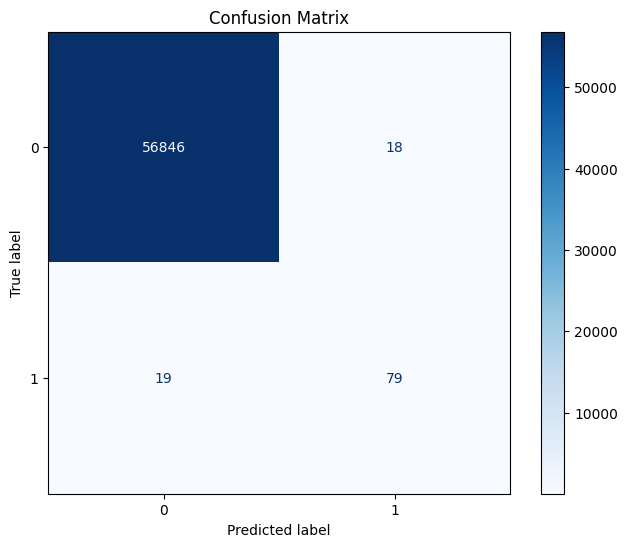


Plotting ROC Curve...


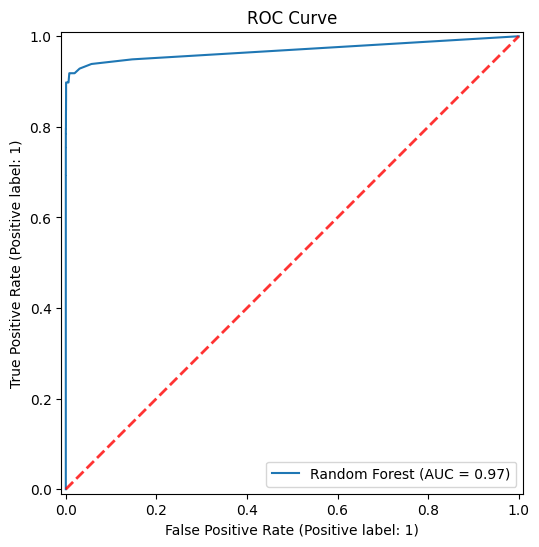


Plotting Feature Importance...


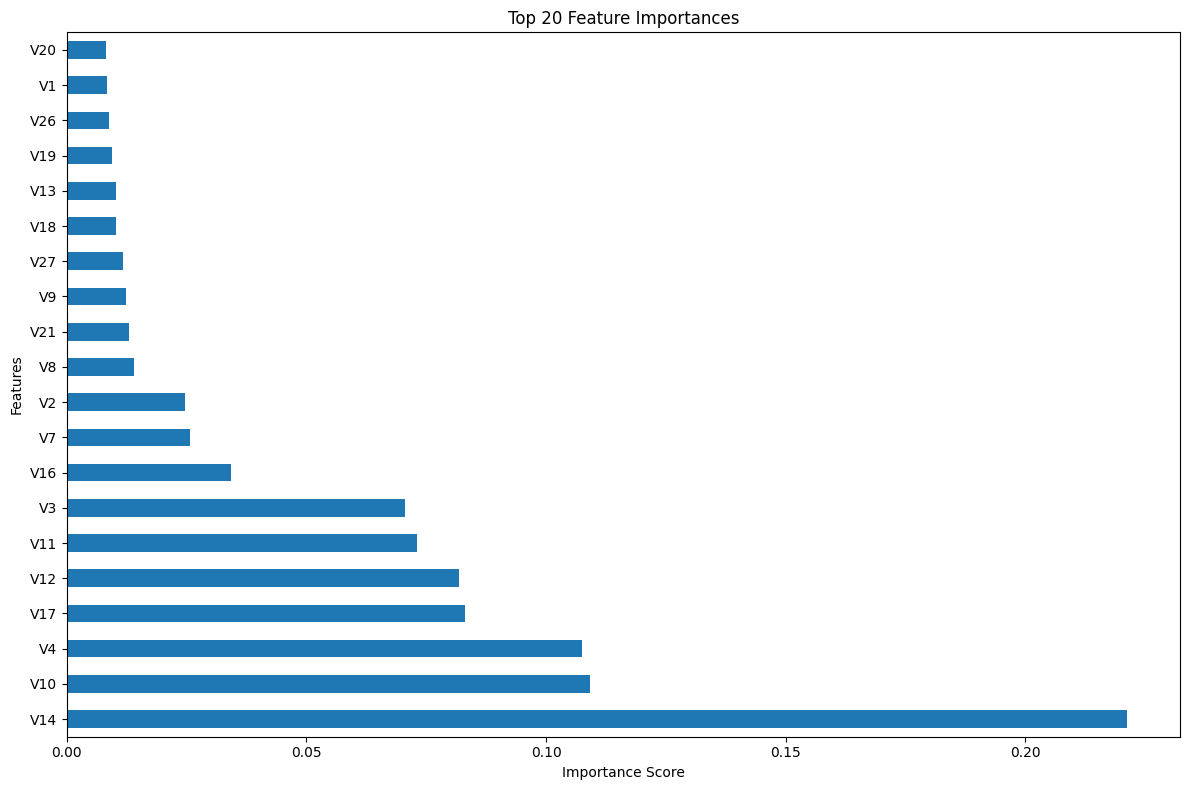

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Plot Confusion Matrix
print('Plotting Confusion Matrix...')
fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap=plt.cm.Blues, ax=ax_cm)
ax_cm.set_title('Confusion Matrix')
plt.grid(False)
plt.show()

# Plot ROC Curve
print('\nPlotting ROC Curve...')
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax_roc, name='Random Forest')
ax_roc.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
ax_roc.set_title('ROC Curve')
plt.show()

# Plot Feature Importance
print('\nPlotting Feature Importance...')
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

fig_fi, ax_fi = plt.subplots(figsize=(12, 8))
feature_importances.nlargest(20).plot(kind='barh', ax=ax_fi) # Display top 20 features
ax_fi.set_title('Top 20 Feature Importances')
ax_fi.set_xlabel('Importance Score')
ax_fi.set_ylabel('Features')
plt.tight_layout()
plt.show()